Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Load our datasets
file_path = 'PrimeRx Datasets.xlsx'
df_alerts = pd.read_excel(file_path, sheet_name='Alerts')
df_sales = pd.read_excel(file_path, sheet_name='Sales')
df_affil = pd.read_excel(file_path, sheet_name='Affiliation')


EDA

In [2]:
# converte to  datetime format
df_alerts['Alert_Date'] = pd.to_datetime(df_alerts['Alert_Date'])
df_sales['Prescription_Date'] = pd.to_datetime(df_sales['Prescription_Date'])

In [3]:
display(df_alerts.head())
display(df_alerts.describe(include='all'))

,Alert_ID,Alert_Date,HCP_ID,Lab_Result
0,ALT001134,2024-03-07,HCP009,Negative
1,ALT008550,2024-10-15,HCP109,Negative
2,ALT008560,2023-07-01,HCP110,Positive
3,ALT006177,2023-12-04,HCP045,Negative
4,ALT008377,2023-07-01,HCP105,Positive


,Alert_ID,Alert_Date,HCP_ID,Lab_Result
count,9537,9537,9537,9537
unique,9537,NaN,220,2
top,ALT000487,NaN,HCP041,Negative
freq,1,NaN,200,5111
mean,NaN,2024-03-31 20:03:23.837684736,NaN,NaN
min,NaN,2023-07-01 00:00:00,NaN,NaN
25%,NaN,2023-11-15 00:00:00,NaN,NaN
50%,NaN,2024-03-30 00:00:00,NaN,NaN
75%,NaN,2024-08-18 00:00:00,NaN,NaN
max,NaN,2024-12-31 00:00:00,NaN,NaN


In [4]:
display(df_sales.head())
display(df_sales.describe(include='all'))

,Prescription_ID,Prescription_Date,HCP_ID,Drug_Name,Drug_ID,Prescription_Volume
0,RX004327,2024-12-31,HCP159,Rivalex,DRG002,22
1,RX005835,2024-12-31,HCP217,Rivalex,DRG002,46
2,RX004207,2024-12-31,HCP156,Nexavir,DRG001,27
3,RX004120,2024-12-31,HCP154,Rivalex,DRG002,44
4,RX002489,2024-12-31,HCP095,Nexavir,DRG001,17


,Prescription_ID,Prescription_Date,HCP_ID,Drug_Name,Drug_ID,Prescription_Volume
count,5917,5917,5917,5917,5917,5917.000000
unique,5917,NaN,177,4,4,NaN
top,RX004346,NaN,HCP185,Nexavir,DRG001,NaN
freq,1,NaN,88,3176,3176,NaN
mean,NaN,2024-03-29 03:11:31.769477632,NaN,NaN,NaN,32.475579
min,NaN,2023-07-01 00:00:00,NaN,NaN,NaN,5.000000
25%,NaN,2023-11-09 00:00:00,NaN,NaN,NaN,18.000000
50%,NaN,2024-03-29 00:00:00,NaN,NaN,NaN,32.000000
75%,NaN,2024-08-19 00:00:00,NaN,NaN,NaN,46.000000
max,NaN,2024-12-31 00:00:00,NaN,NaN,NaN,60.000000


# Question 6: Did alerts actually change doctor behavior? - before vs. after?

Part A: HCP-level before / after lift


In [5]:
# Identify first positive alert date for each doctor
pos_alerts = df_alerts[df_alerts['Lab_Result'].astype(str).str.lower() == 'positive']
first_pos_alert = pos_alerts.groupby('HCP_ID')['Alert_Date'].min().reset_index().rename(columns={'Alert_Date': 'First_Positive_Alert_Date'})

# Filter sales to only our drug (Nexavir)
our_drug_all_sales = df_sales[df_sales['Drug_ID'] == 'DRG001']
our_drug_all_sales


,Prescription_ID,Prescription_Date,HCP_ID,Drug_Name,Drug_ID,Prescription_Volume
2,RX004207,2024-12-31,HCP156,Nexavir,DRG001,27
4,RX002489,2024-12-31,HCP095,Nexavir,DRG001,17
5,RX003164,2024-12-31,HCP119,Nexavir,DRG001,45
6,RX003090,2024-12-31,HCP116,Nexavir,DRG001,50
7,RX003646,2024-12-31,HCP135,Nexavir,DRG001,30
...,...,...,...,...,...,...
5912,RX004825,2023-07-01,HCP185,Nexavir,DRG001,59
5913,RX002928,2023-07-01,HCP111,Nexavir,DRG001,29
5914,RX003463,2023-07-01,HCP131,Nexavir,DRG001,16
5915,RX001744,2023-07-01,HCP069,Nexavir,DRG001,53


In [6]:
base = first_pos_alert.copy()

def get_lift(row):
    hcp = row['HCP_ID']
    alert_date = row['First_Positive_Alert_Date']
    hcp_sales = our_drug_all_sales[our_drug_all_sales['HCP_ID'] == hcp]
    pre = hcp_sales[(hcp_sales['Prescription_Date'] >= alert_date - pd.Timedelta(days=90)) & (hcp_sales['Prescription_Date'] < alert_date)]['Prescription_Volume'].sum()
    post = hcp_sales[(hcp_sales['Prescription_Date'] >= alert_date) & (hcp_sales['Prescription_Date'] <= alert_date + pd.Timedelta(days=90))]['Prescription_Volume'].sum()
    return pd.Series({'Pre_Vol': pre, 'Post_Vol': post})

vols = base.apply(get_lift, axis=1)
df = pd.concat([base, vols], axis=1)
df['Lift %'] = np.where(df['Pre_Vol'] == 0, np.nan, (df['Post_Vol'] - df['Pre_Vol']) / df['Pre_Vol'] * 100)




In [7]:
top10 = df.dropna(subset=['Lift %']).sort_values(by=['Lift %', 'HCP_ID'], ascending=[False, True]).head(10).reset_index(drop=True)
top10['Rank'] = range(1, 11)
partA = top10[['Rank', 'HCP_ID', 'Pre_Vol', 'Post_Vol', 'Lift %']].rename(columns={
    'Pre_Vol': 'Total Prescription Volume Before Alert', 
    'Post_Vol': 'Total Prescription Volume After Alert'
})

display(partA.set_index('Rank'))

,HCP_ID,Total Prescription Volume Before Alert,Total Prescription Volume After Alert,Lift %
Rank,,,,
1,HCP040,8,143,1687.500000
2,HCP050,10,107,970.000000
3,HCP006,32,249,678.125000
4,HCP108,31,238,667.741935
5,HCP016,50,279,458.000000
6,HCP159,42,232,452.380952
7,HCP157,72,387,437.500000
8,HCP211,42,223,430.952381
9,HCP209,64,335,423.437500


Part B: Segment the lift


In [8]:
def segment_hcp(row):
    if row['Pre_Vol'] == 0 and row['Post_Vol'] > 0: return 'New starters'
    elif row['Pre_Vol'] > 0 and row['Lift %'] >= 20: return 'Growers'
    else: return 'Non-responders'

df['Segment'] = df.apply(segment_hcp, axis=1)
segment_summary = df.groupby('Segment').agg(HCPs=('HCP_ID', 'nunique'), Total_Pre=('Pre_Vol', 'sum'), Total_Post=('Post_Vol', 'sum')).reset_index()
segment_summary['Avg Lift %'] = np.where(segment_summary['Total_Pre'] == 0, 'N/A', ((segment_summary['Total_Post'] - segment_summary['Total_Pre']) / segment_summary['Total_Pre'] * 100).round(2))


In [9]:
segment_order = ['New starters', 'Growers', 'Non-responders']
segment_summary['Segment'] = pd.Categorical(segment_summary['Segment'], categories=segment_order, ordered=True)
segment_summary = segment_summary.sort_values('Segment')

display(segment_summary[['Segment', 'HCPs', 'Avg Lift %']].set_index('Segment'))


,HCPs,Avg Lift %
Segment,,
New starters,64,N/A
Growers,25,171.44
Non-responders,125,-56.86


New Starters had the strongest commercial impact because they generated the highest number of new prescriptions (over 9,500) after receiving alerts. While Growers showed the highest percentage growth (+171%), their overall volume contribution was lower. A key concern is the Non-responders segment, where prescriptions dropped by 56%, indicating possible alert fatigue or low engagement with the campaign.

### Visualizing the Lift (Before vs After)


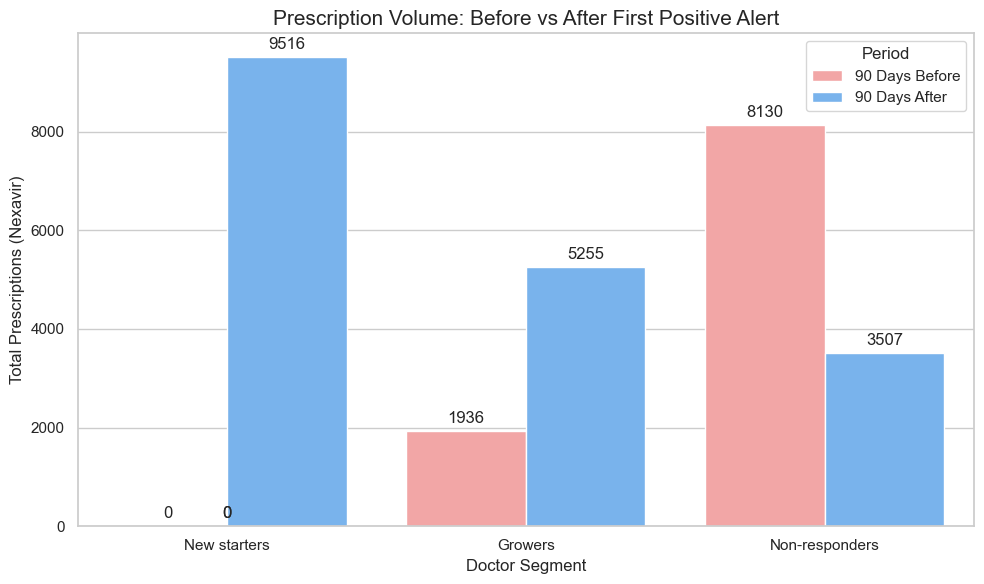

In [10]:
# Plot Before vs After Volume by Segment
plot_data = segment_summary.melt(id_vars='Segment', value_vars=['Total_Pre', 'Total_Post'], 
                                 var_name='Period', value_name='Volume')
plot_data['Period'] = plot_data['Period'].map({'Total_Pre': '90 Days Before', 'Total_Post': '90 Days After'})

plt.figure(figsize=(10, 6))
ax = sns.barplot(data=plot_data, x='Segment', y='Volume', hue='Period', palette=['#ff9999','#66b3ff'])
plt.title('Prescription Volume: Before vs After First Positive Alert', fontsize=15)
plt.ylabel('Total Prescriptions (Nexavir)', fontsize=12)
plt.xlabel('Doctor Segment', fontsize=12)

for p in ax.patches:
    ax.annotate(format(p.get_height(), '.0f'), 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha = 'center', va = 'center', 
                xytext = (0, 9), 
                textcoords = 'offset points')

plt.tight_layout()
plt.show()


## Question 7: Commercial HCP Prioritization


In [11]:
# Total quarterly calls calculation
total_calls = 40 * 20 * 3 * 8

allocation_strategy = {
    'New starters': 0.50, # 50% allocation
    'Growers': 0.30,      # 30% allocation
    'Non-responders': 0.20 # 20% allocation
}


In [12]:
df7 = segment_summary[['Segment', 'HCPs']].copy()
df7['Suggested % of Rep Calls'] = df7['Segment'].astype(str).map(allocation_strategy) * 100
df7['Estimated Quarterly Calls'] = df7['Segment'].astype(str).map(allocation_strategy) * total_calls
df7['Estimated Rep Allocation'] = (df7['Suggested % of Rep Calls'] / 100) * 40

display(df7.set_index('Segment'))

,HCPs,Suggested % of Rep Calls,Estimated Quarterly Calls,Estimated Rep Allocation
Segment,,,,
New starters,64,50.0,9600.0,20.0
Growers,25,30.0,5760.0,12.0
Non-responders,125,20.0,3840.0,8.0


We allocate 50% of resources to New Starters because they have proven to be the strongest source of new prescriptions and need continued support to build long-term prescribing habits. Growers receive 30% since they are highly responsive and offer strong expansion potential. Only 20% is assigned to Non-responders due to their negative ROI, with efforts focused on understanding barriers and collecting feedback rather than driving immediate growth

## Export Results
Export the final answers for Q6 and Q7 to an Excel file.

In [13]:
# Create Excel file
excel_filename = 'Q6_Q7_Results.xlsx'
writer = pd.ExcelWriter(excel_filename, engine='openpyxl')

# Write sheets
partA.to_excel(writer, sheet_name='Q6_Top10_Lift', index=False)
segment_summary.to_excel(writer, sheet_name='Q6_Segment_Summary', index=False)
df7.to_excel(writer, sheet_name='Q7_Sales_Strategy', index=False)

writer.close()
print(f"Data successfully exported to {excel_filename}!")


Data successfully exported to Q6_Q7_Results.xlsx!
